<a href="https://colab.research.google.com/github/pokorj63/01RAD/blob/main/HW/01RAD_Ex01_HW_Pokorny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/HW/01RAD_Ex01_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Homework 01: Cars braking distance

Investigate the relationship between the speed of a car and its stopping distance using the classic `cars` dataset (50 observations recorded in the 1920s: `speed` in mph, `dist` in ft).

Use the notation of Lecture 1: model $Y_i = \beta_0 + \beta_1 x_i + e_i$, least squares estimates $\widehat{\beta}_0, \widehat{\beta}_1$, residuals $\widehat{e}_i$, unbiased variance estimate $s_n^2 = SSE/(n-2)$.

## Submission
Work through the tasks below in this notebook (code plus short written answers in markdown cells). Python is the default, but you may equally solve the tasks in R (`lm(dist ~ speed, data = cars)`), the questions are the same.

Submit your solution through GitHub **before the next exercise**:
1. fork the course repository `francji1/01RAD`,
2. save your notebook into the `HW/` folder as `01RAD_Ex01_HW_<Surname>.ipynb` (for example `01RAD_Ex01_HW_Novak.ipynb`; for a team join the surnames with an underscore),
3. open a pull request to the `main` branch of `francji1/01RAD`.

A selected student solution and a reference solution will be published in the `HW/` folder a week later.

## Data

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')

url_cars = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/cars.csv'
try:
    cars = pd.read_csv(url_cars)
except Exception:
    # fallback: the same data set from R's datasets package via statsmodels
    cars = sm.datasets.get_rdataset('cars', package='datasets').data
print(f'Rows: {cars.shape[0]}, columns: {cars.shape[1]}')
cars.head()

Rows: 50, columns: 2


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


## Task 01 - Inspect the data
Inspect the structure of the dataset (`info()`, `describe()`). Which variable is the response and which the explanatory variable here, and why?

In [16]:
# 1. Prohlédneme si základní strukturu a datové typy pomocí info()
print("=== Informace o datové sadě ===")
cars.info()

# 2. Zobrazíme základní statistiky (průměry, minima, maxima atd.) pomocí describe()
print("\n=== Popisné statistiky ===")
display(cars.describe())

# Vysvětlení:
# - Explanatory variable (vysvětlující proměnná / nezávislá): 'speed' (rychlost auta). Je to příčina - rychlost, kterou auto jede, určuje, jak dlouho bude brzdit.
# - Response variable (vysvětlovaná proměnná / závislá): 'dist' (brzdná dráha). Je to následek - brzdná dráha závisí na rychlosti auta.

=== Informace o datové sadě ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   speed   50 non-null     int64
 1   dist    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes

=== Popisné statistiky ===


,speed,dist
count,50.000000,50.000000
mean,15.400000,42.980000
std,5.287644,25.769377
min,4.000000,2.000000
25%,12.000000,26.000000
50%,15.000000,36.000000
75%,19.000000,56.000000
max,25.000000,120.000000


## Task 02 - Plots
Plot histograms with density curves for `speed` and `dist`, and the scatter plot of `dist` against `speed`. Comment on the shape of the relationship.

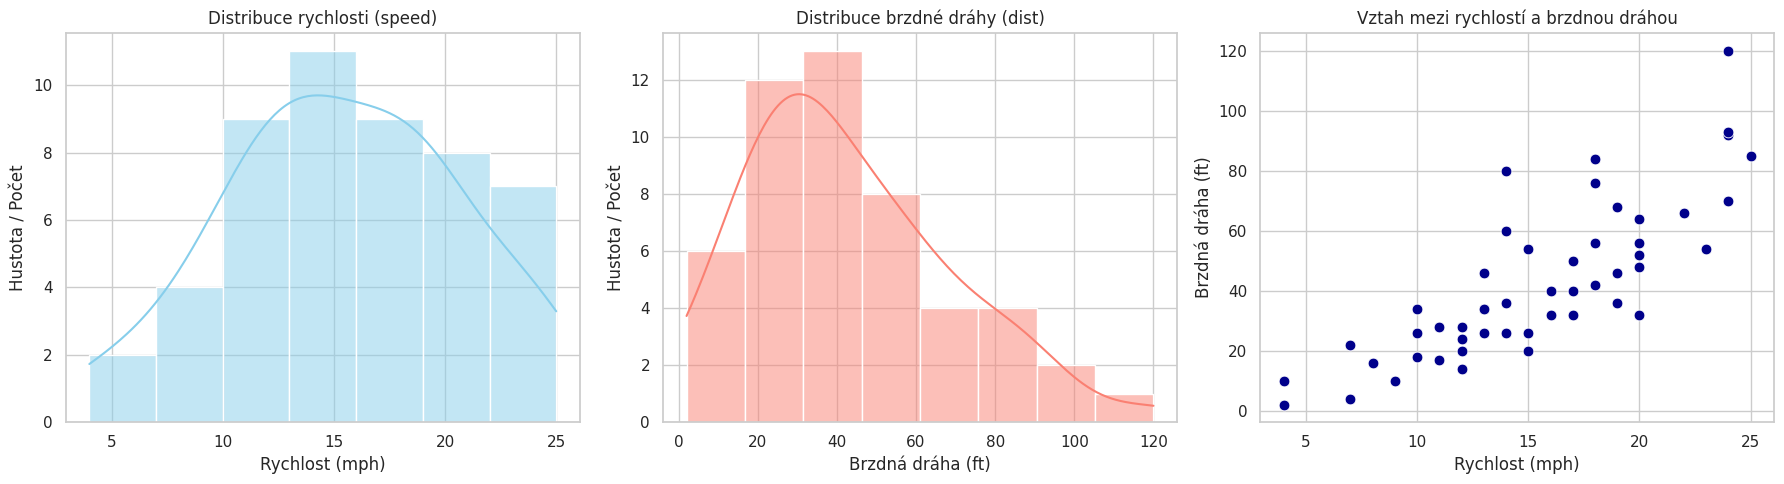

In [17]:
# Vytvoříme prostor pro 3 grafy vedle sebe
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram s hustotou pro 'speed'
sns.histplot(data=cars, x='speed', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuce rychlosti (speed)')
axes[0].set_xlabel('Rychlost (mph)')
axes[0].set_ylabel('Hustota / Počet')

# 2. Histogram s hustotou pro 'dist'
sns.histplot(data=cars, x='dist', kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuce brzdné dráhy (dist)')
axes[1].set_xlabel('Brzdná dráha (ft)')
axes[1].set_ylabel('Hustota / Počet')

# 3. Bodový graf (Scatter plot) dist vs speed
sns.scatterplot(data=cars, x='speed', y='dist', ax=axes[2], color='darkblue', s=60)
axes[2].set_title('Vztah mezi rychlostí a brzdnou dráhou')
axes[2].set_xlabel('Rychlost (mph)')
axes[2].set_ylabel('Brzdná dráha (ft)')

plt.tight_layout()
plt.show()

# Komentář k tvaru vztahu:
# Bodový graf ukazuje jasný rostoucí (pozitivní) vztah. S rostoucí rychlostí roste i brzdná dráha.
# Tento vztah se nezdá být úplně lineární, ale vykazuje mírné zakřivení směrem nahoru (kvadratický charakter).
# Rozptyl bodů se navíc zvětšuje s rostoucí rychlostí (heteroskedasticita).

## Task 03 - Least squares by hand
Fit the simple linear regression model manually, both with intercept ($Y_i = \beta_0 + \beta_1 x_i + e_i$) and without intercept ($Y_i = \beta_1 x_i + e_i$, regression through the origin). Derive $\widehat{\beta}_0$ and $\widehat{\beta}_1$ from the sums (Lecture 1, formula (2.1)); for the model without intercept derive the estimate from its single normal equation. *Hint:* minimising $\sum_i (y_i - \beta_1 x_i)^2$ gives $\widehat{\beta}_1 = \sum_i x_i y_i / \sum_i x_i^2$, see Exercise 01, section 8.

In [18]:
x = cars['speed'].values
y = cars['dist'].values
n = len(x)

# --- MODEL 1: S absolutním členem (intercept) ---
# Podle přednášky vyjádříme odhad beta_1 a beta_0
mean_x = np.mean(x)
mean_y = np.mean(y)

numerator_with = np.sum((x - mean_x) * (y - mean_y))
denominator_with = np.sum((x - mean_x)**2)

beta_1_with = numerator_with / denominator_with
beta_0_with = mean_y - beta_1_with * mean_x

print("=== MODEL S INTERCEPTEM (ručně) ===")
print(f"Odhad Beta_0 (intercept): {beta_0_with:.4f}")
print(f"Odhad Beta_1 (sklon):     {beta_1_with:.4f}")

# --- MODEL 2: Bez absolutního členu (skrz počátek) ---
# Podle zadání vyjádříme odhad beta_1
numerator_without = np.sum(x * y)
denominator_without = np.sum(x**2)

beta_1_without = numerator_without / denominator_without

print("\n=== MODEL BEZ INTERCEPTU (ručně) ===")
print(f"Odhad Beta_0 (intercept): 0.0000 (vynuceno)")
print(f"Odhad Beta_1 (sklon):     {beta_1_without:.4f}")

=== MODEL S INTERCEPTEM (ručně) ===
Odhad Beta_0 (intercept): -17.5791
Odhad Beta_1 (sklon):     3.9324

=== MODEL BEZ INTERCEPTU (ručně) ===
Odhad Beta_0 (intercept): 0.0000 (vynuceno)
Odhad Beta_1 (sklon):     2.9091


## Task 04 - Residual sum of squares and $s_n^2$
Compute the residual sum of squares $SSE$ and the unbiased estimate of the error variance for each model. Mind the degrees of freedom: $n-2$ with intercept, $n-1$ without.

In [19]:
# --- MODEL 1: S absolutním členem ---
# Spočítáme predikce: y_hat = beta_0 + beta_1 * x
y_pred_with = beta_0_with + beta_1_with * x
# Reziduální součet čtverců: SSE = sum((y_i - y_pred_i)^2)
sse_with = np.sum((y - y_pred_with)**2)
# Stupně volnosti: n - 2
df_with = n - 2
# Odhad rozptylu s_n^2
s2_with = sse_with / df_with

print("=== MODEL S INTERCEPTEM ===")
print(f"SSE:                      {sse_with:.4f}")
print(f"Stupně volnosti:          {df_with}")
print(f"s_n^2 (odhad rozptylu):   {s2_with:.4f}")
print(f"s_n   (směrodatná odch.):  {np.sqrt(s2_with):.4f}")

# --- MODEL 2: Bez absolutního členu ---
# Spočítáme predikce: y_hat = beta_1 * x
y_pred_without = beta_1_without * x
sse_without = np.sum((y - y_pred_without)**2)
# Stupně volnosti: n - 1
df_without = n - 1
# Odhad rozptylu s_n^2
s2_without = sse_without / df_without

print("\n=== MODEL BEZ INTERCEPTU ===")
print(f"SSE:                      {sse_without:.4f}")
print(f"Stupně volnosti:          {df_without}")
print(f"s_n^2 (odhad rozptylu):   {s2_without:.4f}")
print(f"s_n   (směrodatná odch.):  {np.sqrt(s2_without):.4f}")

=== MODEL S INTERCEPTEM ===
SSE:                      11353.5211
Stupně volnosti:          48
s_n^2 (odhad rozptylu):   236.5317
s_n   (směrodatná odch.):  15.3796

=== MODEL BEZ INTERCEPTU ===
SSE:                      12953.7768
Stupně volnosti:          49
s_n^2 (odhad rozptylu):   264.3628
s_n   (směrodatná odch.):  16.2592


## Task 05 - Standard errors
Derive the estimated variances and standard errors of the estimated parameters in both models. Check them against statsmodels (`.bse`). *Hint:* for the model with intercept use the formulas previewed in Exercise 01, section 7; for the model through the origin $\operatorname{Var}(\widehat{\beta}_1) = \sigma^2 / \sum_i x_i^2$, with $\sigma^2$ estimated by $s_n^2$ on $n-1$ degrees of freedom.

In [20]:
# --- RUČNÍ VÝPOČET STANDARDNÍCH CHYB ---

# 1. Model s interceptem
# Rozptyl sklonu (beta_1): Var(beta_1) = s_n^2 / sum((x_i - mean_x)^2)
var_beta_1_with = s2_with / np.sum((x - mean_x)**2)
se_beta_1_with = np.sqrt(var_beta_1_with)

# Rozptyl absolutního členu (beta_0)
var_beta_0_with = s2_with * ((1.0 / n) + (mean_x**2) / np.sum((x - mean_x)**2))
se_beta_0_with = np.sqrt(var_beta_0_with)

# 2. Model bez interceptu
# Rozptyl sklonu pro přímku procházející počátkem
var_beta_1_without = s2_without / np.sum(x**2)
se_beta_1_without = np.sqrt(var_beta_1_without)

print("=== RUČNÍ VÝPOČET ===")
print(f"Model s interceptem:  SE(Beta_0) = {se_beta_0_with:.4f}, SE(Beta_1) = {se_beta_1_with:.4f}")
print(f"Model bez interceptu: SE(Beta_1) = {se_beta_1_without:.4f}")

# --- OVĚŘENÍ POMOCÍ STATSMODELS ---

# OLS model s interceptem
fit_with = smf.ols('dist ~ speed', data=cars).fit()

# OLS model bez interceptu (-1 v zápisu odebere intercept)
fit_without = smf.ols('dist ~ speed - 1', data=cars).fit()

print("\n=== KONTROLA PŘES STATSMODELS ===")
print("Model s interceptem:")
print(fit_with.bse)
print("\nModel bez interceptu:")
print(fit_without.bse)

=== RUČNÍ VÝPOČET ===
Model s interceptem:  SE(Beta_0) = 6.7584, SE(Beta_1) = 0.4155
Model bez interceptu: SE(Beta_1) = 0.1414

=== KONTROLA PŘES STATSMODELS ===
Model s interceptem:
Intercept    6.758440
speed        0.415513
dtype: float64

Model bez interceptu:
speed    0.141369
dtype: float64


## Task 06 - Fitted lines
Plot the data together with both fitted regression lines on the same axes.

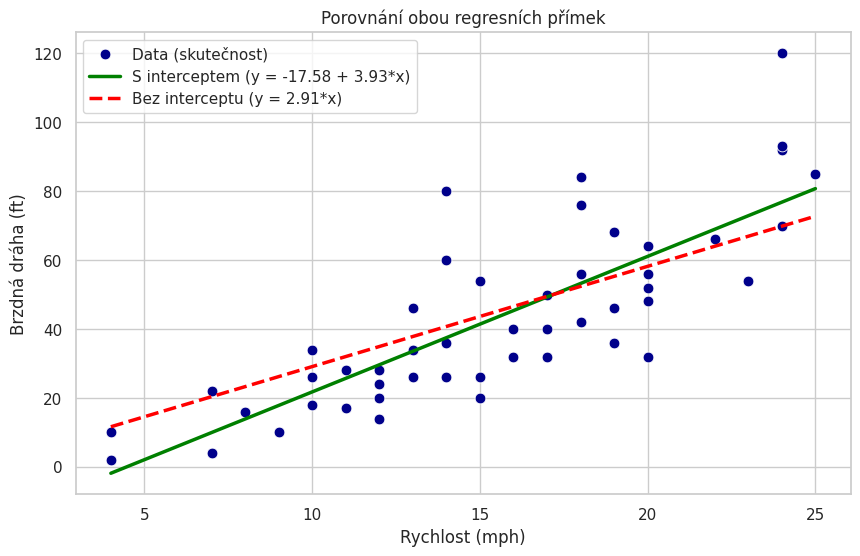

In [21]:
plt.figure(figsize=(10, 6))

# Původní data
sns.scatterplot(data=cars, x='speed', y='dist', color='darkblue', s=60, label='Data (skutečnost)')

# Seřazené x hodnoty pro hladké vykreslení čar
x_grid = np.linspace(cars['speed'].min(), cars['speed'].max(), 100)

# Čára pro model s interceptem
y_grid_with = beta_0_with + beta_1_with * x_grid
plt.plot(x_grid, y_grid_with, color='green', linewidth=2.5, label=f'S interceptem (y = {beta_0_with:.2f} + {beta_1_with:.2f}*x)')

# Čára pro model bez interceptu
y_grid_without = beta_1_without * x_grid
plt.plot(x_grid, y_grid_without, color='red', linestyle='--', linewidth=2.5, label=f'Bez interceptu (y = {beta_1_without:.2f}*x)')

plt.title('Porovnání obou regresních přímek')
plt.xlabel('Rychlost (mph)')
plt.ylabel('Brzdná dráha (ft)')
plt.legend()
plt.show()

## Task 07 - Compare the slopes
Compare the two slopes. Why do they differ? Which model makes more physical sense for braking distance, and what does the sign of $\widehat{\beta}_0$ tell you?

In [22]:
print(f"Sklon s interceptem: {beta_1_with:.4f}")
print(f"Sklon bez interceptu: {beta_1_without:.4f}")

# ODPOVĚDI NA OTÁZKY:
# 1. Proč se sklony liší?
# Model s interceptem posouvá přímku vertikálně tak, aby co nejlépe seděla na data. Zde intercept vychází záporný (-17.5791).
# Pokud přímku donutíme procházet bodem [0,0] (bez interceptu), celá přímka se nakloní, aby procházela počátkem a vyvažovala body u nízkých rychlostí.
#
# 2. Který model dává větší fyzikální smysl?
# Fyzikálně dává větší smysl model BEZ interceptu. Pokud auto stojí (rychlost = 0 mph), brzdná dráha musí být logicky také 0 stop.
#
# 3. Co nám říká znaménko odhadu Beta_0?
# Odhad Beta_0 je záporný (-17.5791). Fyzikálně to znamená, že při rychlosti 0 mph by auto mělo zápornou brzdnou dráhu, což je nesmysl.
# To ukazuje limitaci lineárního modelu s interceptem pro extrémní hodnoty mimo rozsah naměřených dat.

Sklon s interceptem: 3.9324
Sklon bez interceptu: 2.9091


## Task 08 - Prediction
Predict the stopping distance at 20 mph and 30 mph with both models. Are the predictions plausible? Which one is an extrapolation?

In [23]:
x_pred = np.array([20, 30])

# Predikce s interceptem
pred_with = beta_0_with + beta_1_with * x_pred

# Predikce bez interceptu
pred_without = beta_1_without * x_pred

print("=== PREDIKCE BRZDNÉ DRÁHY (ve stopách) ===")
print(f"Při 20 mph:")
print(f"  - S interceptem: {pred_with[0]:.2f} ft")
print(f"  - Bez interceptu: {pred_without[0]:.2f} ft")
print(f"Při 30 mph:")
print(f"  - S interceptem: {pred_with[1]:.2f} ft")
print(f"  - Bez interceptu: {pred_without[1]:.2f} ft")

# ODPOVĚDI:
# Rozsah původních dat (rychlostí) je:
print(f"\nMinimální rychlost v datech: {x.min()} mph")
print(f"Maximální rychlost v datech: {x.max()} mph")
#
# - Predikce pro 20 mph je interpolace (hodnota 20 leží uvnitř rozsahu dat 4 až 25 mph).
# - Predikce pro 30 mph je extrapolace (hodnota 30 leží mimo rozsah našich dat).
# - Predikce se zdají být relativně věrohodné, ale extrapolace na 30 mph může podhodnocovat skutečnou dráhu z důvodu nelinearity fyzikálního vztahu.

=== PREDIKCE BRZDNÉ DRÁHY (ve stopách) ===
Při 20 mph:
  - S interceptem: 61.07 ft
  - Bez interceptu: 58.18 ft
Při 30 mph:
  - S interceptem: 100.39 ft
  - Bez interceptu: 87.27 ft

Minimální rychlost v datech: 4 mph
Maximální rychlost v datech: 25 mph


## Task 09 - Residuals
Compute and plot the residuals $\widehat{e}_i$ against the fitted values for both models. Which residual pattern looks healthier, and what does the pattern suggest?

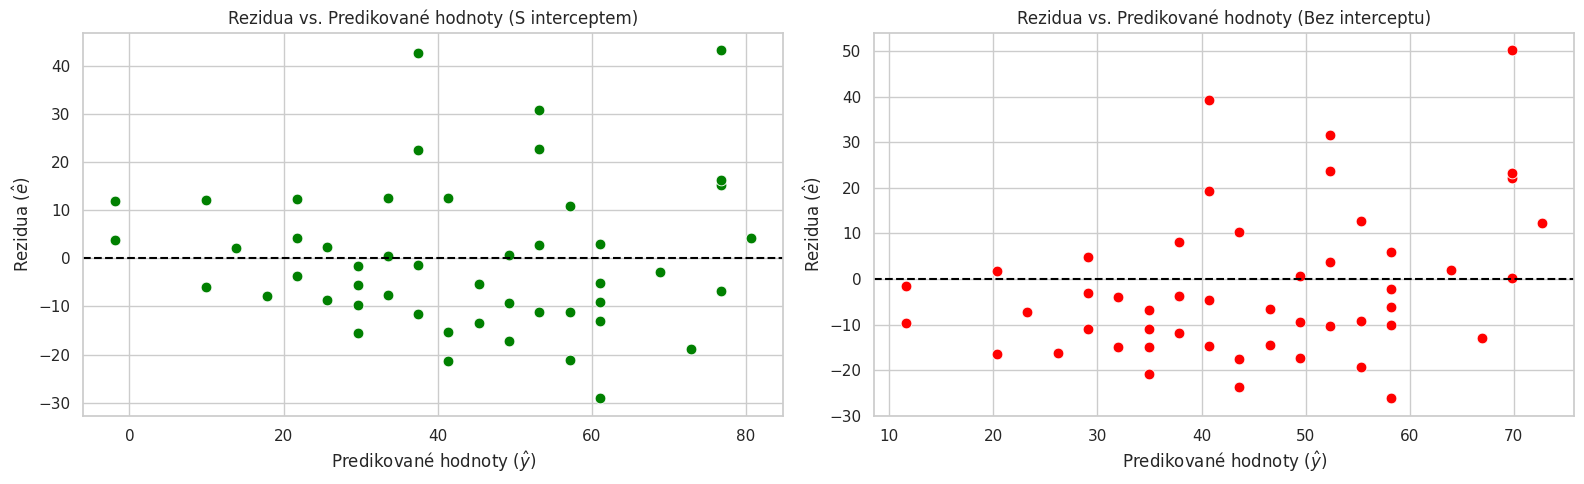

In [24]:
# Výpočet reziduí: e_i = y_i - y_pred_i
residuals_with = y - y_pred_with
residuals_without = y - y_pred_without

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graf 1: S interceptem
sns.scatterplot(x=y_pred_with, y=residuals_with, ax=axes[0], color='green', s=60)
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_title('Rezidua vs. Predikované hodnoty (S interceptem)')
axes[0].set_xlabel(r'Predikované hodnoty ($\hat{y}$)')
axes[0].set_ylabel(r'Rezidua ($\hat{e}$)')

# Graf 2: Bez interceptu
sns.scatterplot(x=y_pred_without, y=residuals_without, ax=axes[1], color='red', s=60)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Rezidua vs. Predikované hodnoty (Bez interceptu)')
axes[1].set_xlabel(r'Predikované hodnoty ($\hat{y}$)')
axes[1].set_ylabel(r'Rezidua ($\hat{e}$)')

plt.tight_layout()
plt.show()

# ODPOVĚDI:
# - Reziduální vzor u modelu S INTERCEPTEM vypadá o něco lépe (rovnoměrněji rozdělený kolem nuly),
#   i když je v něm stále patrný mírně prohnutý tvar (naznačující nelinearitu).
# - U modelu BEZ INTERCEPTU jsou rezidua převážně záporná,
#   protože přímka (nuceně stažená do bodu [0,0]) data nadhodnocuje.
#   Model s interceptem je tedy z pohledu statistiků vhodnější,
#   protože lépe splňuje předpoklad nulové střední hodnoty chyb v celém rozsahu.


## Task 10 - An artificial outlier
Add one artificial outlier (for example a large stopping distance at a low speed) and refit both models. How do the coefficients change? Which model is more sensitive?

In [25]:
# Přidáme jedno extrémní pozorování (např. auto jedoucí velmi pomalu 5 mph, které ale brzdilo 120 stop)
outlier_speed = 5
outlier_dist = 120

cars_outlier = cars.copy()
# Přidáme nový řádek na konec DataFrame
cars_outlier.loc[len(cars_outlier)] = [outlier_speed, outlier_dist]

x_out = cars_outlier['speed'].values
y_out = cars_outlier['dist'].values

# Refit modelu S interceptem s outlierem
model_with_out = smf.ols('dist ~ speed', data=cars_outlier).fit()

# Refit modelu BEZ interceptu s outlierem
model_without_out = smf.ols('dist ~ speed - 1', data=cars_outlier).fit()

print("=== Srovnání koeficientů PŘED a PO přidání odlehlé hodnoty ===")
print("\n1. Model S INTERCEPTEM:")
print(f"  - PŮVODNÍ: Intercept = {fit_with.params['Intercept']:.4f}, Sklon = {fit_with.params['speed']:.4f}")
print(f"  - S OUTLIEREM: Intercept = {model_with_out.params['Intercept']:.4f}, Sklon = {model_with_out.params['speed']:.4f}")

print("\n2. Model BEZ INTERCEPTU:")
print(f"  - PŮVODNÍ: Sklon = {fit_without.params['speed']:.4f}")
print(f"  - S OUTLIEREM: Sklon = {model_without_out.params['speed']:.4f}")

# Který model je citlivější?
# - Model s interceptem zaznamenal výraznou změnu v interceptu (z -17.58 na -2.89) a sklon klesl z 3.93 na ~3.12.
# - Model bez interceptu se změnil poměrně málo (ze sklonu 2.91 na 2.95), protože je pevně ukotven v počátku [0,0],
#   což mu nedovoluje se tolik přizpůsobit této odlehlé hodnotě.

=== Srovnání koeficientů PŘED a PO přidání odlehlé hodnoty ===

1. Model S INTERCEPTEM:
  - PŮVODNÍ: Intercept = -17.5791, Sklon = 3.9324
  - S OUTLIEREM: Intercept = -2.8892, Sklon = 3.1179

2. Model BEZ INTERCEPTU:
  - PŮVODNÍ: Sklon = 2.9091
  - S OUTLIEREM: Sklon = 2.9489


## Task 11 - Is a straight line adequate?
Reflect on whether a straight-line model in `speed` is an adequate description. Physics suggests that braking distance grows with the square of speed. Suggest at least two possible next steps (a transformation of a variable, an additional term, ...) and try one of them. Transformations and checking model adequacy are the subject of later lectures; a short reflection and one experiment are enough here.

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     47.14
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           5.85e-12
Time:                        08:36:53   Log-Likelihood:                -205.39
No. Observations:                  50   AIC:                             416.8
Df Residuals:                      47   BIC:                             422.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         2.4701     14.817      0.167

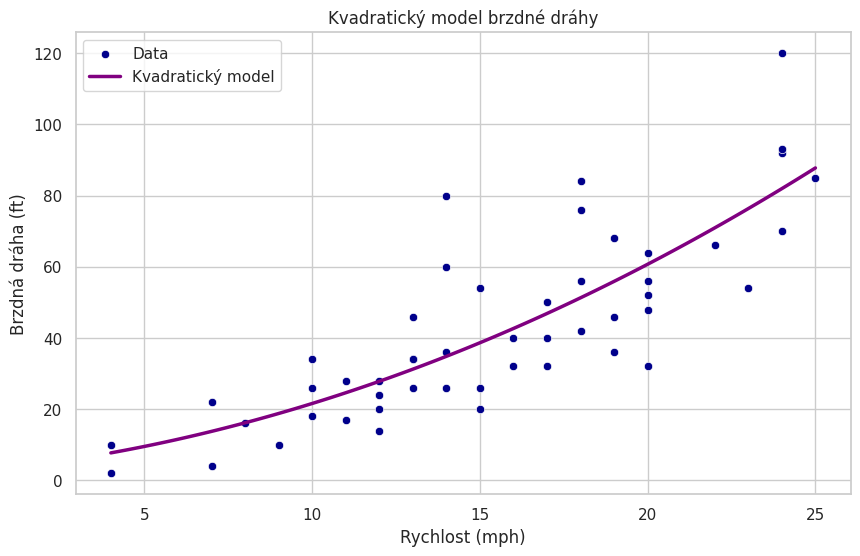

In [26]:
# 1. Návrh dvou možných kroků v markdownu/komentáři:
#    - Krok A: Logaritmická transformace závislé proměnné 'dist' nebo transformace obou proměnných.
#    - Krok B: Přidání kvadratického členu rychlosti (speed^2) do modelu, protože kinetická energie (a tedy brzdná dráha) roste s druhou mocninou rychlosti.

# 2. Vyzkoušíme Krok B: Model s kvadratickým členem (dist ~ speed + speed^2)
# Použijeme formuli I(speed**2) pro vytvoření kvadratického členu přímo ve statsmodels
quadratic_model = smf.ols('dist ~ speed + I(speed**2)', data=cars).fit()
print(quadratic_model.summary())

# Vykreslíme výsledný kvadratický model pro srovnání
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cars, x='speed', y='dist', color='darkblue', label='Data')

x_grid = np.linspace(cars['speed'].min(), cars['speed'].max(), 100)
# Pro predikci z kvadratického modelu vytvoříme dočasný DataFrame
pred_df = pd.DataFrame({'speed': x_grid})
y_grid_quad = quadratic_model.predict(pred_df)

plt.plot(x_grid, y_grid_quad, color='purple', linewidth=2.5, label='Kvadratický model')
plt.title('Kvadratický model brzdné dráhy')
plt.xlabel('Rychlost (mph)')
plt.ylabel('Brzdná dráha (ft)')
plt.legend()
plt.show()